In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s6e5/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e5/train.csv
/kaggle/input/competitions/playground-series-s6e5/test.csv


In [2]:
import torch
import torch.nn as nn
import pandas as pd


In [3]:
train_data = pd.read_csv("/kaggle/input/competitions/playground-series-s6e5/train.csv")
train_data = train_data.drop('id', axis = 1)

In [4]:
train_data.columns

Index(['Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber', 'Stint',
       'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta',
       'Cumulative_Degradation', 'RaceProgress', 'Position_Change',
       'PitNextLap'],
      dtype='object')

In [5]:
train_data.shape

(439140, 15)

In [6]:
#train_data.Driver.unique()
train_data.Race.unique()
#train_data.Compound.unique()

array(['Canadian Grand Prix', 'Dutch Grand Prix', 'Austrian Grand Prix',
       'Pre-Season Testing', 'Azerbaijan Grand Prix',
       'Saudi Arabian Grand Prix', 'Belgian Grand Prix',
       'United States Grand Prix', 'Italian Grand Prix',
       'Hungarian Grand Prix', 'Japanese Grand Prix',
       'São Paulo Grand Prix', 'Bahrain Grand Prix',
       'Las Vegas Grand Prix', 'Monaco Grand Prix', 'British Grand Prix',
       'Australian Grand Prix', 'Spanish Grand Prix', 'Miami Grand Prix',
       'French Grand Prix', 'Abu Dhabi Grand Prix', 'Chinese Grand Prix',
       'Mexico City Grand Prix', 'Emilia Romagna Grand Prix',
       'Singapore Grand Prix', 'Qatar Grand Prix'], dtype=object)

In [7]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

train_data['Driver'] = encoder.fit_transform(train_data['Driver'])
train_data['Compound'] = encoder.fit_transform(train_data['Compound'])
train_data['Race'] = encoder.fit_transform(train_data['Race'])

In [8]:
corr = train_data.corr()

<Axes: >

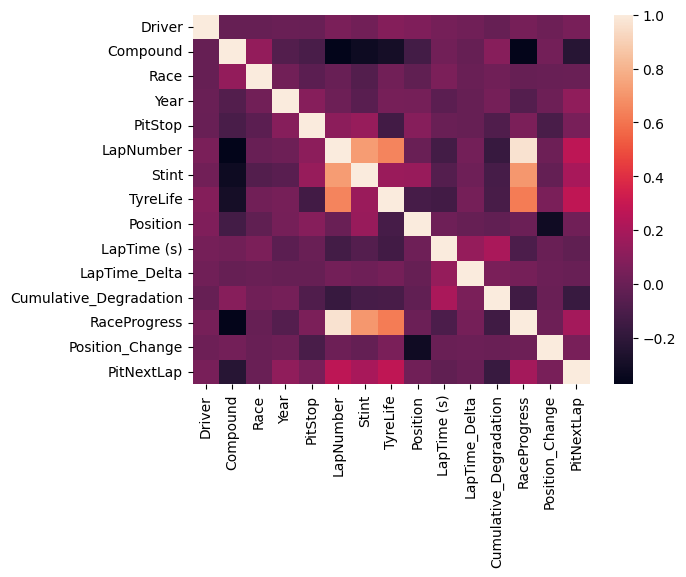

In [9]:
import seaborn as sns

sns.heatmap(corr)

In [10]:

X=torch.tensor(train_data.drop('PitStop',axis = 1).values)
y=torch.tensor(train_data.PitStop.values)

In [11]:
X.shape


torch.Size([439140, 14])

In [12]:
X_cen = (X-X.mean(dim = 0))/X.std(dim=0)

In [13]:
U,S,VT = torch.linalg.svd(X_cen,full_matrices = False)

In [14]:
k = 10

principal_components = VT[:k]

In [15]:
X_pca = X_cen @ principal_components.T

In [16]:
X_pca_numpy = X_pca.numpy()
df_pca = pd.DataFrame(
    X_pca_numpy,
    columns=[f'PC{i+1}' for i in range(X_pca_numpy.shape[1])]
)
corr_matrix = df_pca.corr()

<Axes: >

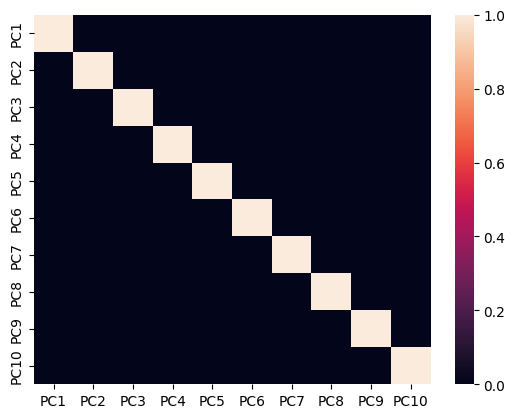

In [17]:
sns.heatmap(corr_matrix)

In [18]:
from sklearn.model_selection import train_test_split

X_pca = X_pca.float()
y = y.long()


X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y,
    test_size=0.2,
    random_state=42
)

In [19]:
X_train = X_train.float()
X_test = X_test.float()
y_train = y_train.long()
y_test = y_test.long()

In [20]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(
    X_train,
    y_train
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

In [21]:
import torch.nn as nn

class PitStopModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
    nn.Linear(10,128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(128,64),
    nn.BatchNorm1d(64),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(64,2)
        )

    def forward(self, x):
        return self.network(x)

In [22]:
model = PitStopModel()

In [23]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.003
)

In [24]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [25]:
model = model.to(device)


In [26]:
print(next(model.parameters()).device)

cuda:0


In [27]:
epochs = 50

for epoch in range(epochs):

    total_loss = 0
    correct = 0
    total = 0

    for batch_X, batch_y in train_loader:

        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        outputs = model(batch_X)

        loss = criterion(outputs, batch_y)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        correct += (
            predictions == batch_y
        ).sum().item()

        total += batch_y.size(0)

    accuracy = 100 * correct / total

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {total_loss:.4f} "
        f"Accuracy: {accuracy:.2f}%"
    )

Epoch [1/50] Loss: 1772.1744 Accuracy: 86.93%
Epoch [2/50] Loss: 1697.4567 Accuracy: 87.14%
Epoch [3/50] Loss: 1686.0069 Accuracy: 87.23%
Epoch [4/50] Loss: 1680.5727 Accuracy: 87.28%
Epoch [5/50] Loss: 1677.4205 Accuracy: 87.34%
Epoch [6/50] Loss: 1670.2498 Accuracy: 87.39%
Epoch [7/50] Loss: 1671.7164 Accuracy: 87.37%
Epoch [8/50] Loss: 1670.4203 Accuracy: 87.35%
Epoch [9/50] Loss: 1666.1180 Accuracy: 87.42%
Epoch [10/50] Loss: 1664.7179 Accuracy: 87.43%
Epoch [11/50] Loss: 1666.9867 Accuracy: 87.40%
Epoch [12/50] Loss: 1667.1710 Accuracy: 87.45%
Epoch [13/50] Loss: 1664.6740 Accuracy: 87.46%
Epoch [14/50] Loss: 1665.8656 Accuracy: 87.42%
Epoch [15/50] Loss: 1663.7679 Accuracy: 87.45%
Epoch [16/50] Loss: 1662.3546 Accuracy: 87.50%
Epoch [17/50] Loss: 1664.2341 Accuracy: 87.48%
Epoch [18/50] Loss: 1661.7550 Accuracy: 87.49%
Epoch [19/50] Loss: 1659.4033 Accuracy: 87.50%
Epoch [20/50] Loss: 1663.1113 Accuracy: 87.43%
Epoch [21/50] Loss: 1663.1602 Accuracy: 87.46%
Epoch [22/50] Loss: 16

In [28]:
model.eval()

PitStopModel(
  (network): Sequential(
    (0): Linear(in_features=10, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=2, bias=True)
  )
)

In [29]:

test_df = pd.read_csv(
    "/kaggle/input/competitions/playground-series-s6e5/test.csv"
)

test_df['Driver'] = encoder.fit_transform(test_df['Driver'])
test_df['Compound'] = encoder.fit_transform(test_df['Compound'])
test_df['Race'] = encoder.fit_transform(test_df['Race'])


test_ids = test_df['id']


test_features = test_df.drop('id', axis=1)


test_tensor = torch.tensor(
    test_features.values,
    dtype=torch.float32
)


test_scaled = (
    test_tensor - X.mean(dim=0).float()
) / X.std(dim=0).float()

principal_components = principal_components.float()
test_pca = test_scaled @ principal_components.T
test_pca.float()

tensor([[-3.4897e+00, -5.8783e+00, -2.2353e+00,  ..., -1.9490e+00,
         -1.0195e+01,  5.4400e+00],
        [ 3.9271e+00, -6.6687e+00, -3.2095e-02,  ..., -1.4663e+00,
         -1.2293e+01,  5.9948e+00],
        [-9.9235e+00, -7.4083e+00, -3.9927e+00,  ..., -3.5758e+00,
         -1.1117e+01,  6.0013e+00],
        ...,
        [ 1.0449e+01, -6.1238e+00,  1.5666e-01,  ..., -5.9554e+00,
         -1.2629e+01,  1.1056e+01],
        [-6.9883e+01, -9.1180e+00, -2.2899e+01,  ..., -9.2972e+00,
         -4.8170e+00,  5.6496e+00],
        [-1.0228e+02, -9.5208e+00, -3.6359e+01,  ..., -1.7278e+01,
          3.7411e+00,  1.3414e+01]])

In [30]:
test_pca = test_pca.to(device)

In [31]:
with torch.no_grad():

    outputs = model(test_pca)

    predictions = torch.argmax(
        outputs,
        dim=1
    )

In [32]:
predictions = predictions.cpu().numpy()

In [33]:
submission = pd.DataFrame({
    'id': test_ids,
    'PitNextLap': predictions
})

In [34]:
submission.to_csv(
    "submission.csv",
    index=False
)

print(submission.head())

       id  PitNextLap
0  439140           1
1  439141           1
2  439142           1
3  439143           0
4  439144           1
